In [17]:
using Plots

In [18]:
include("synthetic_salinity_generation.jl")

simulate_longterm_plume

In [19]:
# 1. Define regular grid dimensions (e.g., 50x50 spatial grid over 100 time steps)
x_coords = collect(range(0.0, stop=100.0, length=50))
y_coords = collect(range(0.0, stop=100.0, length=50))
timestamps = collect(range(0.0, stop=48.0, length=100)) # e.g., 48 hours

# Total grid points = 50 * 50 * 100 = 250,000 points
# Standard Cholesky would require a 250k x 250k matrix (500 GB RAM).
# Kronecker trick requires only 2500x2500 and 100x100 matrices (<50 MB RAM).

# 2. Hyperparameters: [σ², λ_space, λ_time]
params = [4.0, 15.0, 6.0]

# 3. Fast generation
spatial_coords, time_steps, Y_matrix = simulate_large_grid(
    x_coords, y_coords, timestamps, params; 
    mean_val = 25.0, 
    nugget = 0.01
)


([(0.0, 0.0), (0.0, 2.0408163265306123), (0.0, 4.081632653061225), (0.0, 6.122448979591836), (0.0, 8.16326530612245), (0.0, 10.204081632653061), (0.0, 12.244897959183673), (0.0, 14.285714285714286), (0.0, 16.3265306122449), (0.0, 18.367346938775512)  …  (100.0, 81.63265306122449), (100.0, 83.6734693877551), (100.0, 85.71428571428571), (100.0, 87.75510204081633), (100.0, 89.79591836734694), (100.0, 91.83673469387755), (100.0, 93.87755102040816), (100.0, 95.91836734693878), (100.0, 97.95918367346938), (100.0, 100.0)], [0.0, 0.48484848484848486, 0.9696969696969697, 1.4545454545454546, 1.9393939393939394, 2.4242424242424243, 2.909090909090909, 3.393939393939394, 3.878787878787879, 4.363636363636363  …  43.63636363636363, 44.121212121212125, 44.60606060606061, 45.09090909090909, 45.57575757575758, 46.06060606060606, 46.54545454545455, 47.03030303030303, 47.515151515151516, 48.0], [20.774002198989084 19.93081599537976 … 25.83550618638241 25.77461626945491; 21.693059602540337 21.5493263102678

In [20]:
# 4. Convert to DataFrame if needed for downstream tools
df_simulation = grid_to_dataframe(x_coords, y_coords, timestamps, Y_matrix)

Row,x,y,time,y_val
,Float64,Float64,Float64,Float64
1,0.0,0.0,0.0,20.774
2,0.0,0.0,0.484848,19.9308
3,0.0,0.0,0.969697,21.5289
4,0.0,0.0,1.45455,21.2765
5,0.0,0.0,1.93939,21.5566
6,0.0,0.0,2.42424,21.8338
7,0.0,0.0,2.90909,22.0797
8,0.0,0.0,3.39394,23.4328
9,0.0,0.0,3.87879,23.0773


┌ Info: Saved animation to /tmp/jl_OxY9gtg5gn.gif
└ @ Plots /home/kmgovind/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/tmp/jl_OxY9gtg5gn.gif")
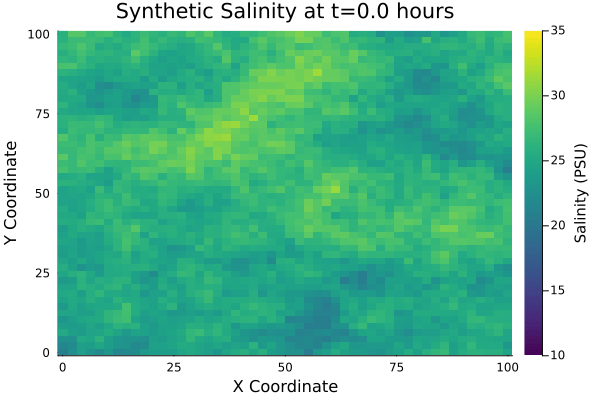

In [21]:
@gif for t in 1:length(timestamps)
    z = reshape(Y_matrix[:, t], length(y_coords), length(x_coords))

    heatmap(
        x_coords,
        y_coords,
        z;
        title = "Synthetic Salinity at t=$(timestamps[t]) hours",
        xlabel = "X Coordinate",
        ylabel = "Y Coordinate",
        colorbar_title = "Salinity (PSU)",
        clims = (10.0, 35.0),
        c = :viridis
    )
end every 5

In [22]:
# 1. Define spatial and temporal grid
x_grid = collect(range(0.0, 500.0, length=40))   # 500 meters East
y_grid = collect(range(0.0, 500.0, length=40))   # 500 meters North
t_grid = collect(range(0.0, 12.0, length=24))    # 12 hours (0.5 hour steps)

# 2. Geostatistical Parameters [Variance, Longitudinal Scale, Transverse Scale, Temporal Scale]
# Notice λ_along (80m) > λ_trans (20m) to create stretched eddies along the plume trajectory
cov_params = [0.5, 80.0, 20.0, 2.0]

# 3. Physical Plume Parameters
plume_config = (
    source_x = 50.0,             # Outfall X coordinate (m)
    source_y = 50.0,             # Outfall Y coordinate (m)
    t0 = 0.0,                    # Release start time (hrs)
    release_rate = 5000.0,       # Mass injection rate (g/s)
    vx = 25.0,                   # Eastward current velocity (m/hr)
    vy = 10.0,                   # Northward current velocity (m/hr)
    diffusion = 30.0,           # Dispersion coefficient (m^2/hr)
    ambient_salinity = 20.0      # Background seawater salinity (PSU)
)

# 4. Generate anisotropic salinity plume
coords, times, S_matrix = simulate_salinity_plume(x_grid, y_grid, t_grid, cov_params, plume_config)

([(0.0, 0.0), (0.0, 12.820512820512821), (0.0, 25.641025641025642), (0.0, 38.46153846153846), (0.0, 51.282051282051285), (0.0, 64.1025641025641), (0.0, 76.92307692307692), (0.0, 89.74358974358974), (0.0, 102.56410256410257), (0.0, 115.38461538461539)  …  (500.0, 384.61538461538464), (500.0, 397.43589743589746), (500.0, 410.2564102564103), (500.0, 423.0769230769231), (500.0, 435.8974358974359), (500.0, 448.71794871794873), (500.0, 461.53846153846155), (500.0, 474.35897435897436), (500.0, 487.1794871794872), (500.0, 500.0)], [0.0, 0.5217391304347826, 1.0434782608695652, 1.565217391304348, 2.0869565217391304, 2.608695652173913, 3.130434782608696, 3.652173913043478, 4.173913043478261, 4.695652173913044  …  7.304347826086956, 7.826086956521739, 8.347826086956522, 8.869565217391305, 9.391304347826088, 9.91304347826087, 10.434782608695652, 10.956521739130435, 11.478260869565217, 12.0], [21.31729329566743 21.210025566875363 … 20.0 20.05433559833357; 20.948200958546238 20.567780343849176 … 20.0

┌ Info: Saved animation to /tmp/jl_UNODStwpqn.gif
└ @ Plots /home/kmgovind/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/tmp/jl_UNODStwpqn.gif")
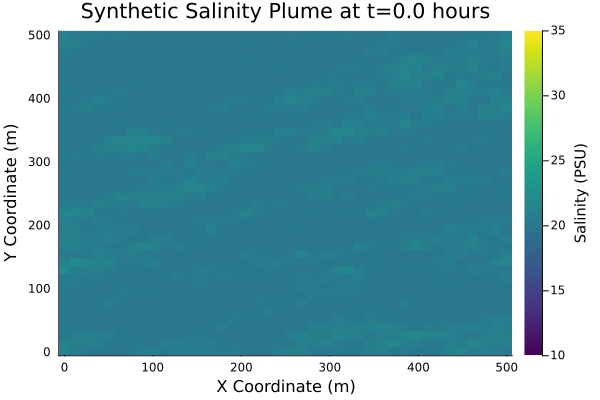

In [23]:
@gif for t in 1:length(t_grid)
    z = reshape(S_matrix[:, t], length(y_grid), length(x_grid))

    heatmap(
        x_grid,
        y_grid,
        z;
        title = "Synthetic Salinity Plume at t=$(t_grid[t]) hours",
        xlabel = "X Coordinate (m)",
        ylabel = "Y Coordinate (m)",
        colorbar_title = "Salinity (PSU)",
        clims = (10.0, 35.0),
        c = :viridis
    )
end

In [24]:
# 1. Spatial Grid
x_grid = collect(range(0.0, 1000.0, length=50))
y_grid = collect(range(0.0, 1000.0, length=50))

# 2. Time parameters: Simulate 1 FULL YEAR (8,760 hours) in 1-hour increments
t_start = 0.0
t_end = 8760.0
dt = 1.0  # 1 hour

# 3. Model Parameters
cov_params = [0.8, 120.0, 30.0, 12.0] # σ², λ_along, λ_trans, λ_time (12-hour memory scale)

plume_config = (
    source_x = 100.0,
    source_y = 500.0,
    t0 = 0.0,
    release_rate = 10000.0,
    vx = 40.0,                  # Current moving East at 40 m/hr
    vy = 5.0,                   # Minor drift North
    diffusion = 250.0,
    ambient_salinity = 32.0
)

# 4. Generate 8,760 frames efficiently in linear time O(N_t)
coords, times, S_3D = simulate_longterm_plume(
    x_grid, y_grid, t_start, t_end, dt, cov_params, plume_config
);

In [26]:
@gif for t in 1:length(t_grid)
    z = reshape(S_matrix[:, t], length(y_grid), length(x_grid))

    heatmap(
        x_grid,
        y_grid,
        z;
        title = "Synthetic Salinity Plume at t=$(t_grid[t]) hours",
        xlabel = "X Coordinate (m)",
        ylabel = "Y Coordinate (m)",
        colorbar_title = "Salinity (PSU)",
        clims = (10.0, 35.0),
        c = :viridis
    )
end every 5

DimensionMismatch: DimensionMismatch: new dimensions (50, 50) must be consistent with array length 1600